# Temporal causal model

`TCMGenerator` samples a temporal structural causal model (SCM): variables are connected through randomly sampled lagged edges, then the system is rolled forward with nonlinear edge functions and stochastic innovations.

$$x_i[t] = \sum_{e \in \mathrm{pa}(i)} f_e\big(x_{j_e}[t - \ell_e]\big) + \varepsilon_i[t]$$

The temporal-SCM framing follows the overview in Runge et al. (2023), [Causal inference for time series](https://doi.org/10.1038/s43017-023-00431-y). SynForecast's graph sampler, edge-function mixture, stability rescaling, and rollout guards are original design choices; this is not a reproduction of a generator from that paper.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from synforecast.generators import TCMGenerator

## Independent SCM draws

In the default univariate mode, each output series comes from a separately sampled SCM. The observed series is one node; other nodes in that SCM act as latent drivers.

In [ ]:
independent_generator = TCMGenerator(
    engine="polars",
    min_length=256,
    max_length=256,
    freq="h",
    n_vars_range=(2, 5),
    max_lag_range=(1, 12),
    seed=42,
)
independent_df = independent_generator.generate(n_series=3)
independent_df.head()

unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,1.345195
"""0""",2000-01-01 01:00:00,-0.067311
"""0""",2000-01-01 02:00:00,-0.248761
"""0""",2000-01-01 03:00:00,-0.196262
"""0""",2000-01-01 04:00:00,0.030754


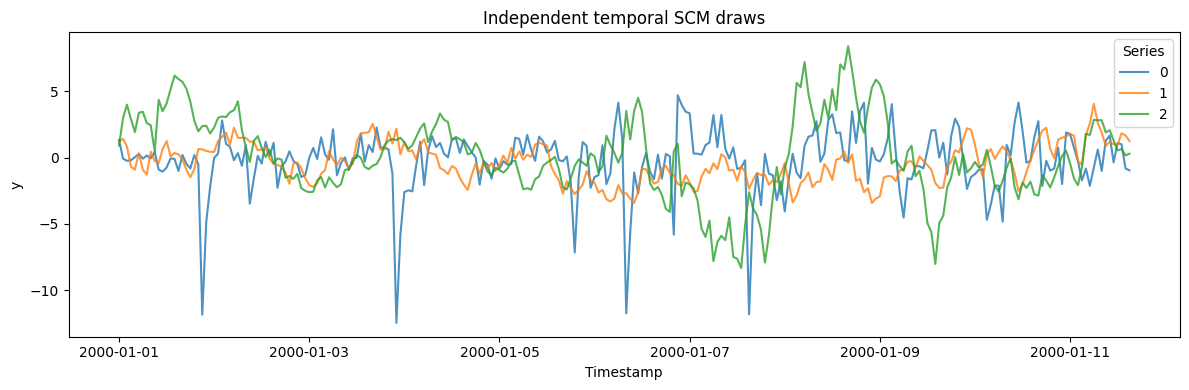

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in independent_df["unique_id"].unique(maintain_order=True):
    series = independent_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"], series["y"], label=str(uid), alpha=0.8)
ax.set(title="Independent temporal SCM draws", xlabel="Timestamp", ylabel="y")
ax.legend(title="Series")
plt.tight_layout()
plt.show()

## Nodes from one shared SCM

Set `multivariate=True` to return several observed nodes from one jointly rolled-out SCM. Because the sampled edges are *lagged*, dependence between nodes appears in lagged cross-correlations rather than in the contemporaneous correlation matrix — and its strength varies pair by pair with the sampled graph: nodes connected by a directed path co-move, nodes without one stay near the noise floor.

Below we compare the maximum absolute cross-correlation over lags 0–12 for every node pair against the same statistic on independent SCM draws.

In [ ]:
joint_generator = TCMGenerator(
    engine="polars",
    min_length=384,
    max_length=384,
    freq="h",
    multivariate=True,
    n_vars_range=(4, 6),
    max_lag_range=(1, 12),
    edge_probability_range=(0.15, 0.3),
    seed=1,
)
joint_df = joint_generator.generate(n_series=4)


# Edges in a temporal SCM are lagged, so dependence between nodes shows up in
# lagged cross-correlations rather than the contemporaneous correlation matrix.
def max_lagged_xcorr(x: np.ndarray, y: np.ndarray, max_lag: int) -> float:
    """Largest |corr(x_t, y_{t-k})| over k = -max_lag..max_lag."""
    best = abs(np.corrcoef(x, y)[0, 1])
    for k in range(1, max_lag + 1):
        best = max(
            best,
            abs(np.corrcoef(x[k:], y[: len(y) - k])[0, 1]),
            abs(np.corrcoef(y[k:], x[: len(x) - k])[0, 1]),
        )
    return best


wide = joint_df.pivot(on="unique_id", index="ds", values="y").sort("ds")
nodes = [column for column in wide.columns if column != "ds"]
values = {node: wide[node].to_numpy() for node in nodes}

# Baseline: the same statistic on independent SCM draws (no shared graph).
independent_baseline_df = TCMGenerator(
    engine="polars", min_length=384, max_length=384, freq="h", seed=101
).generate(n_series=4)
wide_ind = independent_baseline_df.pivot(on="unique_id", index="ds", values="y").sort(
    "ds"
)
ind_nodes = [column for column in wide_ind.columns if column != "ds"]
ind_values = {node: wide_ind[node].to_numpy() for node in ind_nodes}

print("Max |cross-correlation| over lags 0..12 per node pair:\n")
print("  shared SCM (one causal graph):")
for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        xc = max_lagged_xcorr(values[nodes[i]], values[nodes[j]], max_lag=12)
        print(f"    {nodes[i]} vs {nodes[j]}: {xc:.2f}")
print("\n  independent draws (baseline noise level):")
for i in range(len(ind_nodes)):
    for j in range(i + 1, len(ind_nodes)):
        xc = max_lagged_xcorr(ind_values[ind_nodes[i]], ind_values[ind_nodes[j]], 12)
        print(f"    {ind_nodes[i]} vs {ind_nodes[j]}: {xc:.2f}")
joint_df.head()

Max |cross-correlation| over lags 0..12 per node pair:

  shared SCM (one causal graph):
    0 vs 1: 0.32
    0 vs 2: 0.83
    0 vs 3: 0.49
    1 vs 2: 0.18
    1 vs 3: 0.75
    2 vs 3: 0.33

  independent draws (baseline noise level):
    0 vs 1: 0.11
    0 vs 2: 0.11
    0 vs 3: 0.11
    1 vs 2: 0.11
    1 vs 3: 0.11
    2 vs 3: 0.09


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,5.245226
"""0""",2000-01-01 01:00:00,2.547378
"""0""",2000-01-01 02:00:00,1.999835
"""0""",2000-01-01 03:00:00,-0.711531
"""0""",2000-01-01 04:00:00,-2.090204


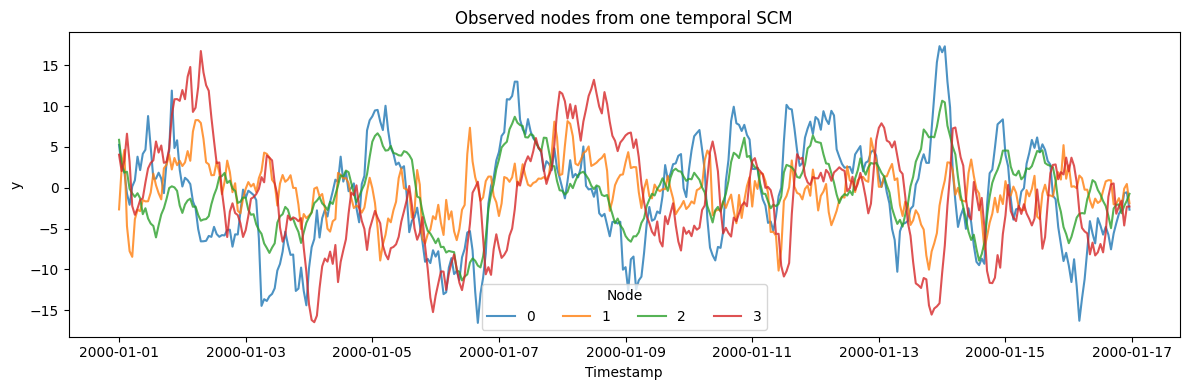

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in joint_df["unique_id"].unique(maintain_order=True):
    series = joint_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"], series["y"], label=str(uid), alpha=0.8)
ax.set(title="Observed nodes from one temporal SCM", xlabel="Timestamp", ylabel="y")
ax.legend(title="Node", ncol=4)
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [TSI](tsi) — trend/seasonal/irregular composition; [KernelSynth](kernel_synth) — GP kernel compositions.
- [VAR](../multivariate/var) — linear multivariate dynamics without a random causal graph.

Full parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::